In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from skimpy import skim
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OneHotEncoder
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import MinMaxScaler
import copy
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform
from random import randint
import optuna
import lightgbm as lgb
import category_encoders as ce
import warnings 

c:\Users\donag\Documents\Projet ENL\.enl\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
data_train = pd.read_csv("../data/raw/train.csv", sep=",")

In [7]:
import os

In [18]:
dir="training"
parent_dir="C:/Users/bradl/Documents/Projets Perso/disease_classification/data/processed"
path = os.path.join(parent_dir,dir)
os.makedirs(path)

In [17]:
data_train.to_csv('../data/processed/training/train.csv')

In [2]:
warnings.filterwarnings("ignore")

# **EDA**

In [4]:
data_train.shape

(15000, 20)

In [5]:
data_train.head()

,id,N_Days,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Status
0,0,1055.0,NaN,19724.0,F,NaN,NaN,NaN,N,1.3,NaN,3.64,NaN,NaN,NaN,NaN,209.0,10.5,3.0,C
1,1,3282.0,Placebo,17884.0,F,N,Y,Y,N,0.7,309.0,3.60,96.0,1142.0,71.3,106.0,240.0,12.4,4.0,C
2,2,1653.0,NaN,20600.0,F,NaN,NaN,NaN,N,2.2,NaN,3.64,NaN,NaN,NaN,NaN,139.0,9.5,2.0,C
3,3,999.0,D-penicillamine,22514.0,F,N,Y,N,N,1.0,498.0,3.35,89.0,1601.0,164.3,85.0,394.0,9.7,3.0,C
4,4,2202.0,NaN,17897.0,F,NaN,NaN,NaN,N,17.2,NaN,3.15,NaN,NaN,NaN,NaN,432.0,11.2,3.0,C


In [6]:
data_train.dtypes

id                 int64
N_Days           float64
Drug              object
Age              float64
Sex               object
Ascites           object
Hepatomegaly      object
Spiders           object
Edema             object
Bilirubin        float64
Cholesterol      float64
Albumin          float64
Copper           float64
Alk_Phos         float64
SGOT             float64
Tryglicerides    float64
Platelets        float64
Prothrombin      float64
Stage            float64
Status            object
dtype: object

In [7]:
# Description Variables catégorielles
skim(data_train.select_dtypes(include="object"))

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 15000  │ │ string      │ 7     │                                                          │
│ │ Number of columns │ 7      │ └─────────────┴───────┘                                                          │
│ └───────────────────┴────────┘                                                                                  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━┳━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓  │
│ ┃           ┃      ┃           ┃          ┃          ┃           ┃         ┃ chars    ┃ words per ┃ total    ┃  │
│ ┃ column    ┃ NA   ┃ NA %      ┃ shortest ┃ longest  ┃ min       ┃ max     ┃ per row  ┃ row       ┃ words    ┃  │
│ ┡━━━━━━━━━━━╇━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩  │
│ │ Drug      │ 6436 │ 42.906666 │ Placebo  │ D-penici │ D-penicil │ Placebo │     11.3 │      0.57 │     8564 │  │
│ │           │      │ 666666666 │          │ llamine  │ lamine    │         │          │           │          │  │
│ │ Sex       │    0 │         0 │ F        │ F        │ F         │ M       │        1 │         1 │    15000 │  │
│ │ Ascites   │ 6437 │ 42.913333 │ N        │ D-penici │ D-penicil │ Y       │        1 │      0.57 │     8563 │  │
│ │           │      │ 333333334 │          │ llamine  │ lamine    │         │          │           │          │  │
│ │ Hepatomeg │ 6436 │ 42.906666 │ Y        │ 119.35   │ 119.35    │ Y       │        1 │      0.57 │     8564 │  │
│ │ aly       │      │ 666666666 │          │          │           │         │          │           │          │  │
│ │ Spiders   │ 6445 │ 42.966666 │ Y        │ Y        │ N         │ Y       │        1 │      0.57 │     8555 │  │
│ │           │      │  66666667 │          │          │           │         │          │           │          │  │
│ │ Edema     │    0 │         0 │ N        │ N        │ N         │ Y       │        1 │         1 │    15000 │  │
│ │ Status    │    0 │         0 │ C        │ CL       │ C         │ D       │     1.03 │         1 │    15000 │  │
│ └───────────┴──────┴───────────┴──────────┴──────────┴───────────┴─────────┴──────────┴───────────┴──────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

In [8]:
# Description Variables numériques
skim(data_train.select_dtypes(include="float64"))

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 15000  │ │ float64     │ 12    │                                                          │
│ │ Number of columns │ 12     │ └─────────────┴───────┘                                                          │
│ └───────────────────┴────────┘                                                                                  │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━┳━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┓  │
│ ┃ column        ┃ NA   ┃ NA %              ┃ mean  ┃ sd     ┃ p0    ┃ p25   ┃ p50   ┃ p75   ┃ p100  ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━╇━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━┩  │
│ │ N_Days        │    0 │                 0 │  1967 │   1356 │     3 │  1092 │  1785 │  2635 │ 40800 │   ▇    │  │
│ │ Age           │    0 │                 0 │ 19250 │   3698 │ 133.3 │ 16370 │ 19540 │ 22370 │ 35470 │   ▅▇▁  │  │
│ │ Bilirubin     │    0 │                 0 │ 1.861 │  2.752 │   0.3 │   0.6 │   0.9 │   1.8 │    28 │   ▇    │  │
│ │ Cholesterol   │ 8331 │             55.54 │ 327.7 │  179.8 │   120 │   242 │   280 │   360 │  1790 │   ▇▂   │  │
│ │ Albumin       │    0 │                 0 │ 3.525 │   0.37 │   1.8 │  3.29 │  3.58 │  3.77 │  4.64 │   ▃▇▅▁ │  │
│ │ Copper        │ 6548 │ 43.65333333333333 │ 74.72 │  74.21 │     4 │    31 │    52 │    86 │   588 │  ▇▁▁   │  │
│ │               │      │                 6 │       │        │       │       │       │       │       │        │  │
│ │ Alk_Phos      │ 6442 │ 42.94666666666666 │  1668 │   1862 │    16 │   721 │  1072 │  1691 │ 19270 │   ▇    │  │
│ │               │      │                 5 │       │        │       │       │       │       │       │        │  │
│ │ SGOT          │ 6445 │ 42.96666666666667 │ 106.6 │  56.49 │     8 │    71 │ 97.65 │ 133.3 │  2148 │   ▇    │  │
│ │ Tryglicerides │ 8370 │              55.8 │ 110.3 │  49.68 │    33 │    80 │    99 │   133 │   598 │   ▇▃   │  │
│ │ Platelets     │  586 │ 3.906666666666666 │ 253.8 │  94.07 │   0.4 │   183 │   251 │   312 │   724 │  ▁▇▇▂  │  │
│ │               │      │                 7 │       │        │       │       │       │       │       │        │  │
│ │ Prothrombin   │   26 │ 0.173333333333333 │ 10.63 │ 0.7419 │   7.1 │  10.1 │  10.6 │    11 │    18 │   ▇▅   │  │
│ │               │      │                34 │       │        │       │       │       │       │       │        │  │
│ │ Stage         │    0 │                 0 │ 3.026 │ 0.8778 │     1 │     2 │     3 │     4 │     4 │ ▁ ▅ ▇▇ │  │
│ └───────────────┴──────┴───────────────────┴───────┴────────┴───────┴───────┴───────┴───────┴───────┴────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

In [5]:
# Nombre de modalités pour chaque variables catégorielles
for i in data_train.select_dtypes(include="object").columns:
    print(f"Nombre de modalité pour la variable:")
    print(data_train[i].value_counts(dropna=False))
    print("\n")

Nombre de modalité pour la variable:
Drug
NaN                6436
D-penicillamine    4568
Placebo            3996
Name: count, dtype: int64


Nombre de modalité pour la variable:
Sex
F    14403
M      597
Name: count, dtype: int64


Nombre de modalité pour la variable:
Ascites
N                  8178
NaN                6437
Y                   383
S                     1
D-penicillamine       1
Name: count, dtype: int64


Nombre de modalité pour la variable:
Hepatomegaly
NaN       6436
N         4564
Y         3999
119.35       1
Name: count, dtype: int64


Nombre de modalité pour la variable:
Spiders
N      6773
NaN    6445
Y      1782
Name: count, dtype: int64


Nombre de modalité pour la variable:
Edema
N    13823
S      811
Y      366
Name: count, dtype: int64


Nombre de modalité pour la variable:
Status
C     10049
D      4560
CL      391
Name: count, dtype: int64




##### Présence de classes très peu représentées pour certaines variables comme "Ascites", qui seront vraisemblablement remplacées par des NaN durant le pre-processing car relatives à des erreurs d'entrées des données.

### Analyse univariée

* ##### Variables numériques

In [10]:
train_num = data_train.select_dtypes(include="float64")

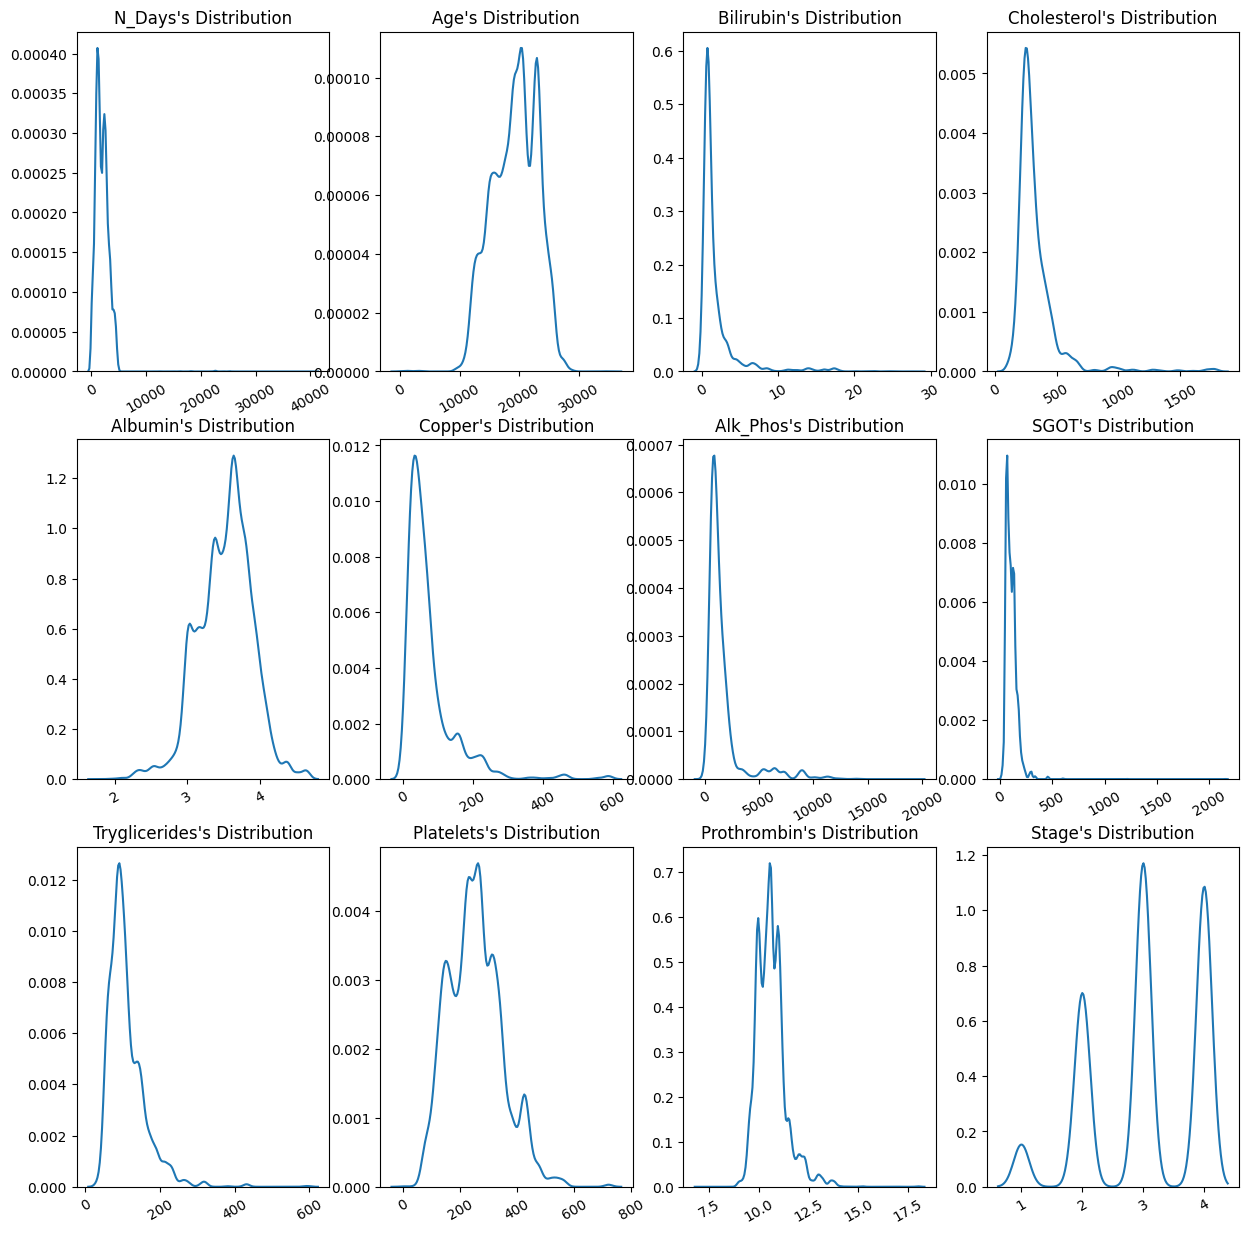

In [ ]:
# KDE plot
i,j = 0,0
fig, axs = plt.subplots(3,4,figsize=(15,15))
for col in train_num.columns:
    sns.kdeplot(data=train_num[col],ax=axs[i][j])
    axs[i][j].set_xticklabels(axs[i][j].get_xticklabels(),rotation=30)
    axs[i][j].set_xlabel(None)
    axs[i][j].set_ylabel(None)
    axs[i][j].set_title(f"{col}'s Distribution")
    j+=1
    if j%4 == 0:
        i+=1
        j=0

##### Variables numériques avec des distributions asymétriques et non normales.

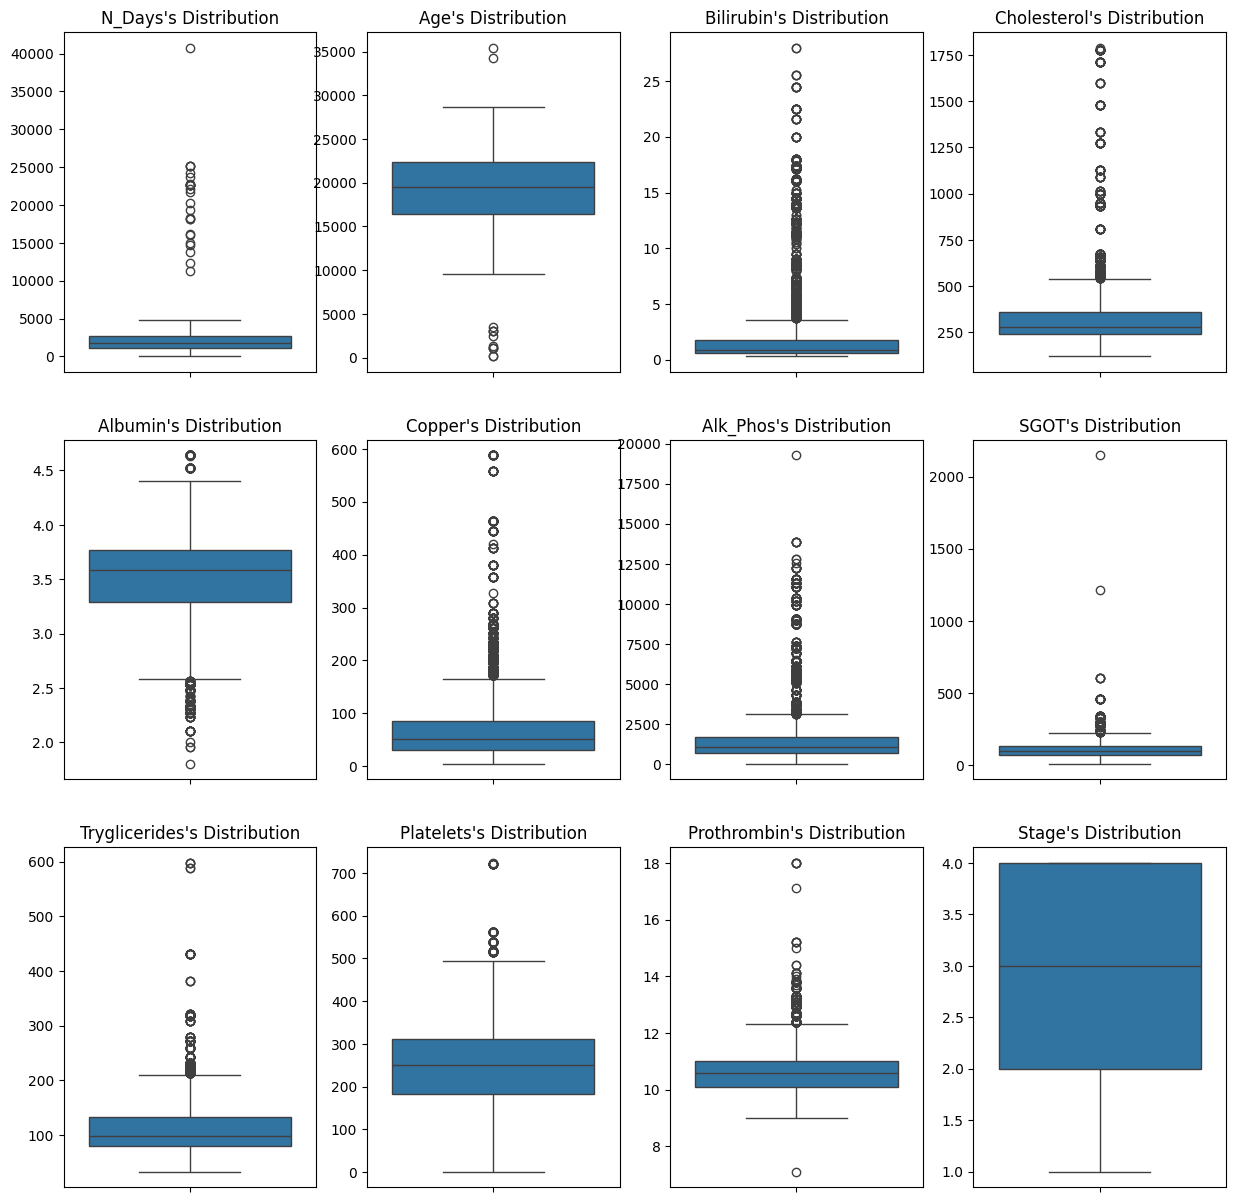

In [ ]:
# Boxplot
i,j = 0,0
fig, axs = plt.subplots(3,4,figsize=(15,15))
for col in train_num.columns:
    sns.boxplot(data=train_num[col],ax=axs[i][j])
    axs[i][j].set_xticklabels(axs[i][j].get_xticklabels(),rotation=30)
    axs[i][j].set_xlabel(None)
    axs[i][j].set_ylabel(None)
    axs[i][j].set_title(f"{col}'s Distribution")
    j+=1
    if j%4 == 0:
        i+=1
        j=0

##### Présence de beaucoup de valeurs extrêmes à traiter, mais également de valeurs aberrantes (du type N_Days = Age, etc) à remplacer par des NaN.

* ##### Variables catégorielles

In [27]:
cat_train = data_train.select_dtypes(include="object")

In [ ]:
# Histogramme
i,j = 1,1
fig = make_subplots(rows=2, cols=4, subplot_titles=[x for x in cat_train.columns.tolist()])

for col in cat_train.columns:
    proportions = cat_train[col].value_counts(normalize=True, dropna=False) * 100
    fig.add_trace(
        go.Bar(x=proportions.index,
               y=proportions.values,
               textposition='inside'),
        row=i, col=j)
    j+=1
    if j%5==0:
        i+=1
        j=1

fig.update_layout(title_text="Répartitions des modalités pour les variables catégorielles",showlegend=False)    

##### Asymétrie de représentation des classes au sein de la variable cible "Status", surreprésentation de la classe "N" pour les variables "Ascites", "Spiders" et "Edema", observations essentiellements constituées de femmes.

### Identification des NaN

In [ ]:
# Nan par variables
data_train.isna().sum()

id                  0
N_Days              0
Drug             6436
Age                 0
Sex                 0
Ascites          6437
Hepatomegaly     6436
Spiders          6445
Edema               0
Bilirubin           0
Cholesterol      8331
Albumin             0
Copper           6548
Alk_Phos         6442
SGOT             6445
Tryglicerides    8370
Platelets         586
Prothrombin        26
Stage               0
Status              0
dtype: int64

##### Beaucoup de NaN à traiter à la fois pour les variables numériques et catégorielles.

### Doublons

In [16]:
data_train[data_train.duplicated()]

,id,N_Days,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Status


##### Aucun doublon

### Analyse bivariée

* ##### Status x Variables quantitatives

In [ ]:
# Boxplots
i,j = 1,1
fig = make_subplots(rows=3, cols=4, subplot_titles=[x for x in train_num.columns.tolist()])

for col in train_num.columns:
    fig.add_trace(
        go.Box(x=data_train["Status"],
               y=data_train[col]),
        row=i, col=j)
    j+=1
    if j%5==0:
        i+=1
        j=1

fig.update_layout(width=1500, height=1500,title_text="Boxplots d'interaction entre Status et les variables numériques",showlegend=False)  

##### Avec ce graphique on obtient une vision plus fine de nos outliers ainsi que des classes au sein de la variable cible, par exemple on remarque pour "SGOT" une observation avec un niveau relativement écarté des autres (2148) ce qui laisse méditer sur la nature de cette observations (est-il humainement possible d'Aspartate Aminotransférase dans le sang?)

* ##### Status x Variables catégorielles

In [ ]:
# Status x Drug
data_contingence = pd.crosstab(data_train["Status"], data_train['Drug'], margins=True)
data_contingence

Drug,D-penicillamine,Placebo,All
Status,,,
C,3147,2672,5819
CL,144,98,242
D,1277,1226,2503
All,4568,3996,8564


##### Potentiel effet positif du D-penicillamine quant à la survie des patients atteint cirrhose biliaire, car mieux représenté au sein de cette population

In [ ]:
# Status x Sex
data_contingence = pd.crosstab(data_train["Status"], data_train['Sex'], margins=True)
data_contingence

Sex,F,M,All
Status,,,
C,9803,246,10049
CL,360,31,391
D,4240,320,4560
All,14403,597,15000


In [ ]:
# Status x Ascites
data_contingence = pd.crosstab(data_train["Status"], data_train['Ascites'], margins=True)
data_contingence

Ascites,D-penicillamine,N,S,Y,All
Status,,,,,
C,1,5803,0,16,5820
CL,0,243,0,0,243
D,0,2132,1,367,2500
All,1,8178,1,383,8563


##### Effet mitigé de la présence d'ascite vis-à-vis des chances de survie à une cirrhose biliaire primaire, car la plupart des décés ne semblaient pas posséder d'ascite.

In [ ]:
# Status x Hepatomegaly
data_contingence = pd.crosstab(data_train["Status"], data_train['Hepatomegaly'], margins=True)
data_contingence

Hepatomegaly,119.35,N,Y,All
Status,,,,
C,0,3981,1834,5815
CL,0,103,140,243
D,1,480,2025,2506
All,1,4564,3999,8564


##### L'augmentation de la taille du foi semble être un signe de dégradation de la maladie puisque c'est un signe relativement chez les personnes décédés au sein de nos données.

In [ ]:
# Status x Spiders
data_contingence = pd.crosstab(data_train["Status"], data_train['Spiders'], margins=True)
data_contingence

Spiders,N,Y,All
Status,,,
C,5205,608,5813
CL,192,50,242
D,1376,1124,2500
All,6773,1782,8555


##### Encore une fois l'effet de cette variable sur le taux de survie n'est pas clair puisque les personnes n'en possédant pas sont à la fois très représentées parmi les patients encore en vie et ceux décédés. Maintenant vu qu'il y en a plus au sein des patients encore en vie, cela signifie qu'il vaut quand même mieux ne pas posséder de spiders afin d'avoir plus de chances de survie.

In [ ]:
# Status x Edema
data_contingence = pd.crosstab(data_train["Status"], data_train['Edema'], margins=True)
data_contingence

Edema,N,S,Y,All
Status,,,,
C,9779,259,11,10049
CL,369,22,0,391
D,3675,530,355,4560
All,13823,811,366,15000


##### La non-présence d'oedème est bien représenté chez la population observée mais également au sein de la population décédé parmi notre échantillon, ne pas avoir d'oedème semble plutôt bénéfique sur la survie des patients à condition que d'autres éléments ne viennent pas compenser son absence (par exemple: la présence d'Ascites).

### Fonctions

In [5]:
# Corrections et changement de format pour certaines colonnes
def val_aberrante_treatment(data:pd.DataFrame):
    
    """
    Fonction permettant de corriger les valeurs n'ayant pas de sens au sein de nos données.

    Arguments:
        data (pd.DataFrame) : Dataframe a modifier.

    Sortie:
        data (pd.DataFrame) : Dataframe modifié.
    """

    ## Correction valeurs aberrantes variables catégorielles
    data["Hepatomegaly"] = data["Hepatomegaly"].replace({"119.35": np.nan})
    data["Ascites"] = data["Ascites"].replace({"D-penicillamine": np.nan, "S": np.nan})

    ## Changement format N_Days et Age
    data["N_Days"] = data["N_Days"]/365
    data["Age"] = data["Age"]/365
    data[["N_Days","Age"]] = data[["N_Days","Age"]].round(decimals=2)
    data.rename(columns={"N_Days" : "N_Years"},inplace=True)
    
    ## Correction valeurs aberrantes variables numériques
    data["N_Years"] = np.where(data["N_Years"]  >= data["Age"], np.nan, data["N_Years"])
    data["Cholesterol"] = np.where(data["Cholesterol"]  > 1000, np.nan, data["Cholesterol"])
    data["Alk_Phos"] = np.where(data["Alk_Phos"]  > 5000, np.nan, data["Alk_Phos"])
    data["SGOT"] = np.where(data["SGOT"]  > 500, np.nan, data["SGOT"])
    
    return data

In [6]:
# Correction outliers
def outliers_treatment(data:pd.DataFrame,col_num:list,method=[None,"bound_replace","nan_replace","median_replace","mean_replace"]):
    
    """
    Fonction permettant de traiter les outliers.

    Arguments:
        data (pd.DataFrame) : Dataframe ayant des outliers à traiter.
        col_num (list) : Liste des colonnes à traiter.
        method : Méthode employée pour le traitement.
    Sortie:
        data (pd.DataFrame) : Dataframe avec outliers traités.

    """

    if method == None:
        print("Aucun traitement effectué")
        return data
    else:
        for col in col_num:
            Q1 = data[col].quantile(0.25)
            Q3 = data[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            ## 1ère technique: on ramène ce qui se trouve au dessus du upper bound et en dessous du lower bound à ces limites
            if method == "bound_replace":
                data[col] = np.where(data[col] < lower_bound, lower_bound, data[col]) #1ère technique
                data[col] = np.where(data[col] > upper_bound, upper_bound, data[col]) #1ère technique
            
            ## 2ème technique: on remplace par nan puis on impute
            elif method == "nan_replace":
                data[col] = np.where(data[col] < lower_bound, np.nan, data[col])
                data[col] = np.where(data[col] > upper_bound, np.nan, data[col])
            
            ## 3ème technique: on remplace par la médiane
            elif method == "median_replace":
                data[col] = np.where(data[col] < lower_bound, np.median(data[col]), data[col]) 
                data[col] = np.where(data[col] > upper_bound, np.median(data[col]), data[col])
            
            ## 4ème technique: on remplace par la moyenne
            elif method == "mean_replace":
                data[col] = np.where(data[col] < lower_bound, np.mean(data[col]), data[col]) 
                data[col] = np.where(data[col] > upper_bound, np.mean(data[col]), data[col])

    return data

In [7]:
# Traitement NaN catégorielles
def cat_nan_treatment(data:pd.DataFrame,cat_col:list, method=["Unknown_col","Mode_col"]):

    """
    Fonction permettant de traiter les NaN des variables catégorielles.

    Arguments:
        data (pd.DataFrame) : Dataframe ayant des outliers à traiter.
        cat_col (list) : Liste des colonnes à traiter.
        method : Méthode employée pour le traitement.
    Sortie:
        data (pd.DataFrame) : Dataframe avec NaN des variables catégorielles traitées.

    """

    ## 1ère technique : remplacer Nan par "Unknown"
    if method == "Unknown_col":
        cat_na = {}
        for i in cat_col:
            cat_na[i] = "Unknown"
        data = data.fillna(value=cat_na)

    ## 2ème technique : remplacer Nan par le mode
    elif method == "Mode_col":
        for col in cat_col:
            data[col] = data[col].fillna(value=data[col].value_counts().idxmax())

    else:
        print("Choisir une méthode prise en charge par le fonction")
        
    return data

In [8]:
# Traitement NaN numériques
def num_nan_treatment(data:pd.DataFrame,num_col:list,num_na:list, method=["KNN","Median","Mean"]):

    """
    Fonction permettant de traiter les NaN des variables numériques.

    Arguments:
        data (pd.DataFrame) : Dataframe ayant des outliers à traiter.
        num_col (list) : Liste des colonnes numériques à utiliser.
        num_na (list) : Liste des colonnes à traiter.
        method : Méthode employée pour le traitement.
    Sortie:
        imputer : imputer entraîné sur les données d'entrée.
        data (pd.DataFrame) : Dataframe avec NaN des variables numériques traitées.

    """

    ## 1ère technique : on remplace les nan en utilisant un KNN 
    if method == "KNN":
        imputer = KNNImputer(n_neighbors=5)
        data_impute = pd.DataFrame(imputer.fit_transform(data_train[num_col]), columns = num_col)
        data[num_na] = data_impute[num_na]
        return data, imputer
    
    ## 2ème technique: on remplace par la médiane
    elif method == "Median":
        data[num_na] = data[num_na].fillna(data[num_na].median())
        return data
    
    ## 3ème technique: on remplace par la moyenne
    elif method == "Mean":
        data[num_na] = data[num_na].fillna(data[num_na].mean())
        return data
    
    else:
        print("Aucun traitement effectué") 
        return data

In [9]:
# Encodage variables catégorielles
def cat_feature_engineering(data:pd.DataFrame,cat_col:list,method=[None,"Label_Ohe","Catboost"]):
    
    """
    Fonction permettant d'encoder les variables numériques.

    Arguments:
        data (pd.DataFrame) : Dataframe ayant des outliers à traiter.
        cat_col (list) : Liste des colonnes à traiter.
        method : Méthode employée pour le traitement.
    Sortie:
        data (pd.DataFrame) : Dataframe avec NaN des variables catégorielles traités.
        encoder : encoder entraîné sur les données d'entrée.

    """
    
    if method == None:
        print("Aucun traitement effectué")
        return data
    
    ## 1ère technique: on map les variables sous forme de 3 classes, sauf pour Drug -> One Hot
    elif method == "Label_Ohe":
        for col in cat_col:
            if col == "Drug":
                col_list = [col]
                encoder = OneHotEncoder()
                one_hot_encoded = encoder.fit_transform(data[col_list]).toarray()
                one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(col_list))
                data = pd.concat([data, one_hot_df.drop(columns=[f"{col}_Unknown"])], axis=1)
            elif col == "Sex":
                data[f"{col}_encoded"] = np.where(data[col] == "F",1,0)
            elif col == "Edema":
                data[f"{col}_encoded"] = data[col].map({"Y":2, "N":0, "S":1})
            elif col == "Status":
                data[f"{col}_encoded"] = data[col].map({"CL":2, "C":1, "D":0})
            else:
                data[f"{col}_encoded"] = data[col].map({"Y":2, "N":1, "Unknown":0})
            return data, encoder

    ## 2ème technique :  on encode à l'aide de l'encodage du CatBoost -> Target encoding modifié     
    else:
        cat_col.remove("Status")
        data["Status_encoded"] = data["Status"].map({"CL":2, "C":1, "D":0})
        encoder = ce.cat_boost.CatBoostEncoder(handle_missing="return_nan") 
        encoder.fit(data[cat_col], data["Status_encoded"]) 
        data[cat_col] = encoder.transform(data[cat_col])
        return data, encoder

In [10]:
# Transformation variables numériques
def num_feature_engineering(data:pd.DataFrame,col_fe=list,method=["Log","Standard","Robust","MinMax"]): 

    """
    Fonction permettant de traansformer les variables numériques.

    Arguments:
        data (pd.DataFrame) : Dataframe ayant des outliers à traiter.
        col_fe (list) : Liste des colonnes à traansformer.
        method : Méthode employée pour la transformation.
    Sortie:
        data (pd.DataFrame) : Dataframe avec NaN des variables catégorielles traités.
        scaler : méthode de transformation affinée sur les données d'entrée.

    """

    ## 1ère technique : on utilise le log
    if method == "Log":
        for col in col_fe:
            data[f"{col}_log"] = np.log(data[col])
        return data
    
    ## 2ème technique : on standardise
    elif method == "Standard":
        scaler = StandardScaler()
        data[col_fe] = scaler.fit_transform(data[col_fe])
        return data, scaler

    ## 3ème technique : on utilise un robust scaler
    elif method == "Robust":
        scaler = RobustScaler()
        data[col_fe] = scaler.fit_transform(data[col_fe])
        return data, scaler

    ## 4ème technique :  on utlise un minmax scaler
    elif method == "MinMax":
        scaler = MinMaxScaler()
        data[col_fe] = scaler.fit_transform(data[col_fe])
        return data, scaler

    else:
        print("Aucune transformation effectuée")
        return data


# **Modélisation**

### **Régression polytomique**

In [67]:
data_train = pd.read_csv("Data/train.csv", sep=",")

* #### *Pre-processing*

In [68]:
#Correction des variables erronées
data_train = val_aberrante_treatment(data_train)

#Traitement des outliers
col_num = data_train.select_dtypes(include="float64").columns.tolist()
data_train = outliers_treatment(data_train,col_num,method="bound_replace")

#Traitement des NaN variables catégorielles
cat_col = data_train.select_dtypes(include="object").columns.tolist()
data_train = cat_nan_treatment(data_train, cat_col, method="Unknown_col")

#Traitement des NaN variables numériques
na_series = data_train.select_dtypes(include="float64").isna().sum()
col_num_na = na_series[na_series > 0].index.tolist()
data_train, knn_imputer = num_nan_treatment(data_train,col_num,col_num_na,method="KNN")

#Encodage des variables catégorielles
col_cat = data_train.select_dtypes(include="object").columns.tolist()
data_train, encoder = cat_feature_engineering(data_train,col_cat,method="Catboost")

#Transformation de certaines variables
transfo = ["Cholesterol","Alk_Phos","Tryglicerides","Platelets"]
data_train, scaler = num_feature_engineering(data_train,transfo,method="Standard")

In [69]:
data_train

,id,N_Years,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,...,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Status,Status_encoded
0,0,2.89,0.703545,54.04,0.730611,0.702907,0.703747,0.703494,0.760831,1.3,...,3.64,85.1,0.252413,79.554,-0.171009,-0.482926,10.50,3.0,C,1
1,1,8.99,0.717719,49.00,0.730611,0.769009,0.528681,0.397489,0.760831,0.7,...,3.60,96.0,0.081924,71.300,0.007120,-0.142516,12.35,4.0,C,1
2,2,4.53,0.703545,56.44,0.730611,0.702907,0.703747,0.703494,0.760831,2.2,...,3.64,42.8,-0.480145,79.290,0.070737,-1.251592,9.50,2.0,C,1
3,3,2.74,0.751964,61.68,0.730611,0.769009,0.528681,0.825173,0.760831,1.0,...,3.35,89.0,1.078793,164.300,-0.660863,1.548550,9.70,3.0,C,1
4,4,6.03,0.703545,49.03,0.730611,0.702907,0.703747,0.703494,0.760831,3.6,...,3.15,39.8,-0.413687,80.600,0.029386,1.965826,11.20,3.0,C,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,14995,5.02,0.717719,55.57,0.730611,0.769009,0.917354,0.397489,0.760831,1.0,...,3.68,52.0,0.331684,60.450,3.394745,-0.274288,9.90,3.0,C,1
14996,14996,1.67,0.751964,67.36,0.730611,0.043547,0.528681,0.825173,0.031940,1.8,...,3.14,18.0,-0.278599,97.650,-0.737203,-1.394345,11.00,4.0,D,0
14997,14997,8.49,0.717719,56.00,0.730611,0.769009,0.528681,0.397489,0.760831,0.9,...,3.93,168.5,-0.371988,120.000,1.279467,0.757922,10.60,4.0,C,1
14998,14998,12.20,0.703545,49.03,0.730611,0.702907,0.703747,0.703494,0.760831,2.1,...,3.63,40.2,-0.022323,79.578,0.188429,-0.219383,11.00,4.0,D,0


* #### *Training*

In [70]:
# Train
X = data_train.select_dtypes(exclude=("object")).drop(columns=["id","Status_encoded"])
Y = data_train["Status_encoded"]
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=16)
clf = LogisticRegression(solver="newton-cg", n_jobs=-1,max_iter=2000)
clf.fit(x_train,y_train)

# Predict
y_pred = clf.predict_proba(x_test)
y_pred_train = clf.predict_proba(x_train)
metric_train = log_loss(y_train, y_pred_train)
metric_test = log_loss(y_test, y_pred)
print("Log-loss train set:", metric_train)
print("Log-loss validation set:", metric_test)

Log-loss train set: 0.43939508392307447
Log-loss validation set: 0.42588322655509275


### **CatBoost**

In [17]:
data_train = pd.read_csv("Data/train.csv", sep=",")

* #### *Pre-processing*

In [18]:
# Correction des valeurs erronées
data_train = val_aberrante_treatment(data_train)

# Traitement des outliers
col_num = data_train.select_dtypes(include="float64").columns.tolist()
data_train = outliers_treatment(data_train,col_num,method="nan_replace")

# Traitement des NaN variables catégorielles
cat_col = data_train.select_dtypes(include="object").columns.tolist()
data_train = cat_nan_treatment(data_train, cat_col, method="Unknown_col")

In [19]:
data_train

,id,N_Years,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Status
0,0,2.89,Unknown,54.04,F,Unknown,Unknown,Unknown,N,1.3,NaN,3.64,NaN,NaN,NaN,NaN,209.0,10.5,3.0,C
1,1,8.99,Placebo,49.00,F,N,Y,Y,N,0.7,309.0,3.60,96.0,1142.0,71.30,106.0,240.0,NaN,4.0,C
2,2,4.53,Unknown,56.44,F,Unknown,Unknown,Unknown,N,2.2,NaN,3.64,NaN,NaN,NaN,NaN,139.0,9.5,2.0,C
3,3,2.74,D-penicillamine,61.68,F,N,Y,N,N,1.0,498.0,3.35,89.0,1601.0,164.30,85.0,394.0,9.7,3.0,C
4,4,6.03,Unknown,49.03,F,Unknown,Unknown,Unknown,N,NaN,NaN,3.15,NaN,NaN,NaN,NaN,432.0,11.2,3.0,C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,14995,5.02,Placebo,55.57,F,N,N,Y,N,1.0,322.0,3.68,52.0,1257.0,60.45,NaN,228.0,9.9,3.0,C
14996,14996,1.67,D-penicillamine,67.36,F,Y,Y,N,Y,1.8,NaN,3.14,18.0,976.0,97.65,NaN,126.0,11.0,4.0,D
14997,14997,8.49,Placebo,56.00,F,N,Y,Y,N,0.9,348.0,3.93,NaN,933.0,120.00,146.0,322.0,10.6,4.0,C
14998,14998,12.20,Unknown,49.03,F,Unknown,Unknown,Unknown,N,2.1,NaN,3.63,NaN,NaN,NaN,NaN,233.0,11.0,4.0,D


* #### *Optimisation*

Random Search

In [20]:
# Initialisation du modèle
X = data_train.drop(columns=["id","Status"])
Y = data_train["Status"]
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=16)
cat_features = [1,3,4,5,6,7]

distrib = {"iterations":[500,1000],
          "learning_rate":uniform(loc=0.1, scale=0.8),
          "depth":list(range(4, 11)),
           "border_count":list(range(50,254))
          }

catboost = CatBoostClassifier(loss_function="MultiClass")

# Random Search
random_search = RandomizedSearchCV(catboost,distrib,scoring="neg_log_loss",n_jobs=-1,cv=3,n_iter=5,random_state=16)
model_search = random_search.fit(x_train,y_train,cat_features=cat_features,verbose=False)

# Evaluation
y_pred_train = model_search.predict_proba(x_train)
y_pred = model_search.predict_proba(x_test)
metric_train = log_loss(y_train, y_pred_train)
metric_test = log_loss(y_test, y_pred)
print("Log-loss train set:", metric_train)
print("Log-loss validation set:", metric_test)

Log-loss train set: 0.19985424882632674
Log-loss validation set: 0.40401835739075037


Optuna

In [ ]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [71]:
#Optimisation avec Optuna
def objective(trial):
    X = data_train.drop(columns=["id","Status"])
    Y = data_train["Status"]
    x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=16)
    cat_features = [1,3,4,5,6,7]
    
    # Hyperparamètres
    iterations = trial.suggest_int("iterations",100,1500)
    learning_rate = trial.suggest_uniform("learning_rate",0.1,0.9)
    depth = trial.suggest_int("depth", 2, 16)
    border_count = trial.suggest_int("border_count",25,500)

    #Entraînement et évaluation
    catboost = CatBoostClassifier(iterations=iterations,
                                  learning_rate=learning_rate,
                                  depth=depth,
                                  border_count=border_count,
                                  loss_function="MultiClass")
    catboost.fit(x_train,y_train,cat_features = cat_features, verbose=False)
    y_pred = catboost.predict_proba(x_test)
    metric_test = log_loss(y_test, y_pred)

    return metric_test

In [ ]:
# Spécification de l'optimisation
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=10)

#Résultat
print("Best hyperparameters:", study.best_params)
print("Best value:", study.best_value)

Best hyperparameters: {'iterations': 377, 'learning_rate': 0.210751086669541, 'depth': 3, 'border_count': 345}
Best value: 0.3727625311663269


* #### *Training*

In [74]:
X = data_train.drop(columns=["id","Status"])
Y = data_train["Status"]
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=16)
cat_features = [1,3,4,5,6,7]
catboost = CatBoostClassifier(iterations=377,
                                  learning_rate=0.210751086669541,
                                  depth=3,
                                  border_count=345,
                                  loss_function="MultiClass")
catboost.fit(x_train,y_train,cat_features = cat_features, verbose=False)


y_pred = catboost.predict_proba(x_test)
y_pred_train = catboost.predict_proba(x_train)
metric_train = log_loss(y_train, y_pred_train)
metric_test = log_loss(y_test, y_pred)
print("Log-loss train set:", metric_train)
print("Log-loss validation set:", metric_test)

Log-loss train set: 0.33462631992925124
Log-loss validation set: 0.37279266860771654


### **LightGBM**

In [24]:
data_train = pd.read_csv("Data/train.csv", sep=",")

* #### *Pre-processing*

In [25]:
#Correction des valeurs erronées
data_train = val_aberrante_treatment(data_train)

#Traitement des outliers
col_num = data_train.select_dtypes(include="float64").columns.tolist()
data_train = outliers_treatment(data_train,col_num,method="nan_replace")

#Encodage des variables catégorielles
col_cat = data_train.select_dtypes(include="object").columns.tolist()
data_train, encoder = cat_feature_engineering(data_train,col_cat,method="Catboost")

In [26]:
data_train

,id,N_Years,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,...,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Status,Status_encoded
0,0,2.89,NaN,54.04,0.730611,NaN,NaN,NaN,0.760831,1.3,...,3.64,NaN,NaN,NaN,NaN,209.0,10.5,3.0,C,1
1,1,8.99,0.717719,49.00,0.730611,0.769009,0.528681,0.397489,0.760831,0.7,...,3.60,96.0,1142.0,71.30,106.0,240.0,NaN,4.0,C,1
2,2,4.53,NaN,56.44,0.730611,NaN,NaN,NaN,0.760831,2.2,...,3.64,NaN,NaN,NaN,NaN,139.0,9.5,2.0,C,1
3,3,2.74,0.751964,61.68,0.730611,0.769009,0.528681,0.825173,0.760831,1.0,...,3.35,89.0,1601.0,164.30,85.0,394.0,9.7,3.0,C,1
4,4,6.03,NaN,49.03,0.730611,NaN,NaN,NaN,0.760831,NaN,...,3.15,NaN,NaN,NaN,NaN,432.0,11.2,3.0,C,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,14995,5.02,0.717719,55.57,0.730611,0.769009,0.917354,0.397489,0.760831,1.0,...,3.68,52.0,1257.0,60.45,NaN,228.0,9.9,3.0,C,1
14996,14996,1.67,0.751964,67.36,0.730611,0.043547,0.528681,0.825173,0.031940,1.8,...,3.14,18.0,976.0,97.65,NaN,126.0,11.0,4.0,D,0
14997,14997,8.49,0.717719,56.00,0.730611,0.769009,0.528681,0.397489,0.760831,0.9,...,3.93,NaN,933.0,120.00,146.0,322.0,10.6,4.0,C,1
14998,14998,12.20,NaN,49.03,0.730611,NaN,NaN,NaN,0.760831,2.1,...,3.63,NaN,NaN,NaN,NaN,233.0,11.0,4.0,D,0


* #### *Optimisation*

Optuna

In [14]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [15]:
def objective(trial):
    X = data_train.select_dtypes(exclude="object").drop(columns=["id","Status_encoded"])
    Y = data_train["Status_encoded"]
    x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=16)
    
    #Hyperparamètres
    n_estimators = trial.suggest_int("n_estimators",100,2000)
    learning_rate = trial.suggest_uniform("learning_rate",0.1,0.9)
    max_depth = trial.suggest_int("max_depth", 2, 30)
    subsample = trial.suggest_float("subsample",0.1,1)
    reg_lambda = trial.suggest_float("reg_lambda",0,20)
    
    #Entraînement et évaluation
    model_lgb = lgb.LGBMClassifier(n_estimators=n_estimators,learning_rate=learning_rate,
                                   max_depth=max_depth, reg_lambda=reg_lambda,subsample=subsample,
                                   objective='multiclass',metric='multi_logloss',random_state=15,n_jobs=-1,
                                  )
    model_lgb.fit(x_train,y_train)
    y_pred = model_lgb.predict_proba(x_test)
    metric_test = log_loss(y_test, y_pred)

    return metric_test

In [16]:
#Spécification de l'optimisation
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=150, n_jobs=-1)

#Résultat
print("Best hyperparameters:", study.best_params)
print("Best value:", study.best_value)

Best hyperparameters: {'n_estimators': 101, 'learning_rate': 0.13043140101998155, 'max_depth': 26, 'subsample': 0.8670723161862206, 'reg_lambda': 17.393983610142048}
Best value: 0.36758224287455415


* #### *Training*

In [88]:
X = data_train.select_dtypes(exclude="object").drop(columns=["id","Status_encoded"])
Y = data_train["Status_encoded"]
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=16)

model_lgb = lgb.LGBMClassifier(n_estimators=244,
                               learning_rate=0.20233405798370685,
                               max_depth=2,
                               subsmple=0.563294855422829,
                               reg_lambda=0.6439531561278,
                               objective='multiclass',
                               metric='multi_logloss',
                               random_state=15,
                               verbosity=-1
                              )
model_lgb.fit(x_train,y_train)

y_pred = model_lgb.predict_proba(x_test)
y_pred_train = model_lgb.predict_proba(x_train)
metric_train = log_loss(y_train, y_pred_train)
metric_test = log_loss(y_test, y_pred)
print("Log-loss train set:", metric_train)
print("Log-loss validation set:", metric_test)

Log-loss train set: 0.30878837547469123
Log-loss validation set: 0.3611647916907214


In [90]:
X = data_train.select_dtypes(exclude="object").drop(columns=["id","Status_encoded"])
Y = data_train["Status_encoded"]
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=16)

model_lgb = lgb.LGBMClassifier(n_estimators=202,
                               learning_rate=0.2147040466653362,
                               max_depth=2,
                               subsmple=0.8966356592054007,
                               reg_lambda=16.773730571801373,
                               objective='multiclass',
                               metric='multi_logloss',
                               random_state=15,
                               verbosity=-1
                              )
model_lgb.fit(x_train,y_train)

y_pred = model_lgb.predict_proba(x_test)
y_pred_train = model_lgb.predict_proba(x_train)
metric_train = log_loss(y_train, y_pred_train)
metric_test = log_loss(y_test, y_pred)
print("Log-loss train set:", metric_train)
print("Log-loss validation set:", metric_test)

Log-loss train set: 0.3301452062796845
Log-loss validation set: 0.36688417442092897


In [91]:
X = data_train.select_dtypes(exclude="object").drop(columns=["id","Status_encoded"])
Y = data_train["Status_encoded"]
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=16)

model_lgb = lgb.LGBMClassifier(n_estimators=551,
                               learning_rate=0.10035446511204754,
                               max_depth=2,
                               subsmple=0.5078208763469587,
                               reg_lambda=4.585402455658456,
                               objective='multiclass',
                               metric='multi_logloss',
                               random_state=15,
                               verbosity=-1
                              )
model_lgb.fit(x_train,y_train)

y_pred = model_lgb.predict_proba(x_test)
y_pred_train = model_lgb.predict_proba(x_train)
metric_train = log_loss(y_train, y_pred_train)
metric_test = log_loss(y_test, y_pred)
print("Log-loss train set:", metric_train)
print("Log-loss validation set:", metric_test)

Log-loss train set: 0.3117781283737828
Log-loss validation set: 0.3633097731241707


In [37]:
y_pred = model_lgb.predict_proba(x_test)
metric_test = log_loss(y_test, y_pred)
metric_test

0.3633097731241707

# **Test du modèle choisi**

In [27]:
data_test = pd.read_csv("Data/test.csv", sep=",")
data_test

,id,N_Days,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,15000,611.0,D-penicillamine,21828.0,F,N,Y,N,N,0.8,198.0,3.90,39.0,855.0,66.65,56.0,295.0,10.5,4.0
1,15001,2103.0,NaN,21915.0,F,NaN,NaN,NaN,N,0.6,NaN,3.81,NaN,NaN,NaN,NaN,269.0,10.5,3.0
2,15002,130.0,NaN,23011.0,F,NaN,NaN,NaN,N,0.7,NaN,3.94,NaN,NaN,NaN,NaN,425.0,10.8,4.0
3,15003,1635.0,NaN,20089.0,F,NaN,NaN,NaN,N,0.6,NaN,3.50,NaN,NaN,NaN,NaN,248.0,10.3,2.0
4,15004,3336.0,D-penicillamine,15031.0,F,N,N,N,N,0.5,NaN,4.52,29.0,766.0,74.40,NaN,474.0,10.1,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,24995,976.0,NaN,19358.0,F,NaN,NaN,NaN,N,0.7,NaN,3.29,NaN,NaN,NaN,NaN,350.0,10.5,3.0
9996,24996,2504.0,D-penicillamine,16094.0,F,N,Y,N,N,0.6,271.0,3.20,80.0,804.0,97.65,55.0,311.0,9.7,3.0
9997,24997,2111.0,NaN,21185.0,F,NaN,NaN,NaN,N,0.8,NaN,2.27,NaN,NaN,NaN,NaN,209.0,9.9,1.0
9998,24998,3358.0,D-penicillamine,17246.0,F,N,N,N,N,0.9,NaN,3.85,58.0,1273.0,173.60,NaN,233.0,9.7,3.0


In [101]:
#Nombre de modalité pour chaque variables catégorielles
for i in data_test.select_dtypes(include="object").columns:
    print(f"Nombre de modalité pour la variable:")
    print(data_test[i].value_counts(dropna=False))
    print("\n")

Nombre de modalité pour la variable:
Drug
NaN                4340
D-penicillamine    3036
Placebo            2623
Drug                  1
Name: count, dtype: int64


Nombre de modalité pour la variable:
Sex
F    9631
M     369
Name: count, dtype: int64


Nombre de modalité pour la variable:
Ascites
N      5401
NaN    4334
Y       265
Name: count, dtype: int64


Nombre de modalité pour la variable:
Hepatomegaly
NaN    4335
N      3138
Y      2527
Name: count, dtype: int64


Nombre de modalité pour la variable:
Spiders
N      4529
NaN    4340
Y      1130
C         1
Name: count, dtype: int64


Nombre de modalité pour la variable:
Edema
N    9269
S     502
Y     229
Name: count, dtype: int64




In [28]:
# Correction valeurs erronées
data_test["Drug"] = data_test["Drug"].replace({"Drug": np.nan})
data_test["Spiders"] = data_test["Spiders"].replace({"C": np.nan})

# Traitement des outliers
data_test = val_aberrante_treatment(data_test)
col_num = data_test.select_dtypes(include="float64").columns.tolist()
data_test = outliers_treatment(data_test,col_num,method="nan_replace")

# Encodage des variables catégorielles
col_cat = data_test.select_dtypes(include="object").columns.tolist()
data_test[col_cat] = encoder.transform(data_test[col_cat])

In [29]:
train_set = data_train.select_dtypes(exclude="object").drop(columns=["id","Status_encoded"])
target = data_train["Status_encoded"]
test_set = data_test.drop(columns=["id"])

model = lgb.LGBMClassifier(n_estimators=551,
                               learning_rate=0.10035446511204754,
                               max_depth=2,
                               subsmple=0.5078208763469587,
                               reg_lambda=4.585402455658456,
                               objective='multiclass',
                               metric='multi_logloss',
                               random_state=15,
                               verbosity=-1
                              )
model.fit(train_set,target)
y_pred_test = model.predict_proba(test_set)

In [30]:
df_clf = pd.DataFrame(index=data_test.index)
df_clf["id"] = data_test["id"]
df_clf[["Status_D","Status_C","Status_CL"]] = y_pred_test
df_clf = df_clf.iloc[:,[0,2,3,1]]
df_clf

,id,Status_C,Status_CL,Status_D
0,15000,0.807070,0.003770,0.189161
1,15001,0.945173,0.004069,0.050758
2,15002,0.785472,0.004546,0.209982
3,15003,0.964970,0.004763,0.030267
4,15004,0.983576,0.005812,0.010612
...,...,...,...,...
9995,24995,0.847785,0.015695,0.136520
9996,24996,0.985077,0.006688,0.008236
9997,24997,0.952778,0.000636,0.046586
9998,24998,0.912349,0.025646,0.062005


In [ ]:
#df_clf.to_csv("Soumissions/submit_enl.csv",index=False)